# Import

In [37]:
import pyxdf

import os
import sys

import math
import mne
import numpy as np

import matplotlib.pyplot as plt


import scipy.stats as stats
from scipy.fftpack import fft
from scipy import signal
from sklearn.decomposition import PCA

from hypyp import analyses

# Helper functions

In [2]:
## Auxiliar function

def butter_highpass_filter(data, cutoff, fs, order=5):
    data=np.array(data)
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    print(data.shape)
    y = signal.filtfilt(b, a, data)
    return y

def butter_lowpass_filter(data, cutoff, fs, order=5):
    data=np.array(data)
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    print(data.shape)
    y = signal.filtfilt(b, a, data)
    return y

def butter_bandpass_filter(data, HPcutoff, LPcutoff, fs, order=5):
    data=np.array(data)
    b, a = signal.butter(order, [HPcutoff, LPcutoff], btype='bandpass', analog=False, fs=fs)
    print(data.shape)
    y = signal.filtfilt(b, a, data)
    return y

def IMU_wavelet(IMU_data, IMU_SR, wavelet, level, threshold, LPF):
    coeffs = pywt.wavedec(IMU_data, wavelet, level=level)
    coeffs_thresholded = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]
    denoised_IMU = pywt.waverec(coeffs_thresholded, wavelet)
    
    IMU_trg = np.sqrt(np.mean(denoised_IMU,axis=1)**2)
    a = np.transpose(IMU_trg)
    return np.transpose(butter_lowpass_filter(a,LPF,IMU_SR, 5))

def sliding_pearson(x, y, window_size, norm=True, windowNorm=False):
    """Calculates the sliding Pearson correlation coefficient.

    Args:
        x (np.ndarray): The first signal.
        y (np.ndarray): The second signal.
        window_size (int): The size of the sliding window.

    Returns:
        np.ndarray: An array of Pearson correlation coefficients for each window.
    """
    if norm==True:
        x=x/np.max(x)
        y=y/np.max(y)

    if len(x) != len(y):
        raise ValueError("Signals must have the same length")

    if window_size < 1:
        raise ValueError("Window size must be positive")

    num_windows = len(x) - window_size + 1
    corr_coeff = np.empty(num_windows)
    #np.pad(x, (window_size))
    #np.pad(y,(window_size))

    for i in range(num_windows):
        window_x = x[i:i+window_size]
        window_y = y[i:i+window_size]
        if windowNorm == True:
            rms = (np.sqrt(np.mean(window_x**2))+np.sqrt(np.mean(window_y**2)))/2
            corr_coeff[i] = rms*np.corrcoef(window_x, window_y)[0, 1]
        else:
            corr_coeff[i] = np.corrcoef(window_x, window_y)[0, 1]
    
    
    return np.pad(corr_coeff,(int(window_size)-20))

def timeConv(x):
    minute = x // 60
    second = round(x % 60, 3)
    return minute,second

def sec2frame (minutes, seconds):
    fps = 30
    totalSeconds = seconds + minutes*60
    return int(totalSeconds*fps)

def frame2sec(frame):
    fps = 30
    totalSeconds = frame/fps
    minutes, d = divmod(totalSeconds/60, 1)
    seconds = d*60
    return (minutes), (seconds)

def find_nearest(base_TS, ref_TS):
    arr = np.asarray(base_TS)
    indexes = np.zeros(len(ref_TS), dtype=int)
    for i, value in enumerate(ref_TS):
        indexes[i] = int((np.abs(arr - value)).argmin())
    return indexes, base_TS[indexes]

def creatEvents_synched(IMU_data, timeStamp, threshold, MOI=None, marker=1):
    trg = rising_edge(IMU_data, threshold)
    events = np.zeros(len(timeStamp))
    events[trg] = marker
    return events


def creatEvents(IMU_data, IMU_timeStamp, EEG_timeStamp, threshold, MOI=None, marker = 1):
    trg = rising_edge(IMU_data, threshold)
    idx,values = find_nearest(EEG_timeStamp, IMU_timeStamp[trg])

    events = np.zeros(len(EEG_timeStamp))
    events[idx] = marker
    return events

def rising_edge(data, thresh):
    sign = data >= thresh
    risingPos = np.where(np.convolve(sign, [1, -1]) == 1)[0]
    
    debounce_threshold = 100
    for preIdx in range(len(risingPos)-1):
        idx = preIdx+1
        if risingPos[idx]-risingPos[preIdx] < debounce_threshold:
            risingPos[idx] = 0
    events = risingPos[risingPos != 0]
    return events

def MOI(MOI, timeStamps):
    MOI_idx = np.zeros([len(MOI),2])
    ts = np.zeros([len(MOI),2])
    frameOffset = int(video[0][0])
    
    for i, value in enumerate(MOI):
        init_min = value[0][0]
        init_sec = value[0][1]
        end_min = value[1][0]
        end_sec = value[1][1]
    
        MOI_init_TS = videoTS[sec2frame(init_min,init_sec)-frameOffset]
        MOI_end_TS = videoTS[sec2frame(end_min,end_sec)-frameOffset]
    
        MOI_idx[i][0], ts[i][0] = find_nearest(timeStamps, np.array([MOI_init_TS]))
        MOI_idx[i][1], ts[i][1] = find_nearest(timeStamps, np.array([MOI_end_TS]))

    return MOI_idx.astype(int), ts

def find_close_events(events1, EEG_timeStamp1, events2, EEG_timeStamp2, threshold, markerLeft, markerRight, marker):
    """
    Find and match events that occur close together in time between two EEG recordings.
    
    Parameters:
    -----------
    events1, events2 : numpy arrays
        Event markers for the two EEG recordings
    EEG_timeStamp1, EEG_timeStamp2 : numpy arrays
        Timestamps for the two EEG recordings
    threshold : float
        Maximum time difference allowed between matching events
    markerLeft, markerRight : int
        Event marker values to look for in each recording
    marker : int
        New marker value to assign to matched events
    
    Returns:
    --------
    events1, events2 : numpy arrays
        New event arrays with matched events marked
    """
    
    # Get timestamps where events occur in each recording
    idx1 = np.where(events1 == markerLeft)
    timestamps1 = EEG_timeStamp1[idx1]
    
    idx2 = np.where(events2 == markerRight) 
    timestamps2 = EEG_timeStamp2[idx2]
    
    # Handle case where no events found
    if len(timestamps1) == 0 or len(timestamps2) == 0:
        print("empty")
        return np.zeros(len(EEG_timeStamp1)), np.zeros(len(EEG_timeStamp2))

    # Find nearest events in recording 2 for each event in recording 1
    _, nearest_timestamps2 = find_nearest(timestamps2, timestamps1)
    
    # Keep only events that are within threshold time difference
    time_diff = np.abs(nearest_timestamps2 - timestamps1)
    matching_mask = time_diff < threshold
    
    matching_times1 = timestamps1 * matching_mask
    matching_times2 = nearest_timestamps2 * matching_mask
    
    # Calculate temporal offset between matching events
    offset = (matching_times1 - matching_times2)/2
    
    # Create new event arrays with matched events
    # Adjust timing by the calculated offset
    idx1, _ = find_nearest(EEG_timeStamp1, matching_times1 - offset)
    new_events1 = np.zeros(len(EEG_timeStamp1))
    new_events1[idx1] = marker
    
    idx2, _ = find_nearest(EEG_timeStamp2, matching_times2 + offset)
    new_events2 = np.zeros(len(EEG_timeStamp2))
    new_events2[idx2] = marker
    
    # Clear first sample to avoid edge effects
    new_events1[0] = 0
    new_events2[0] = 0
    
    return new_events1, new_events2


def find_far_events(events1, EEG_timeStamp1, events2, EEG_timeStamp2, threshold, markerLeft, markerRight, marker):
    """
    Find events that are separated by more than a threshold time difference between two EEG recordings.
    
    Parameters:
    -----------
    events1, events2 : numpy arrays
        Event markers for the first and second EEG recordings
    EEG_timeStamp1, EEG_timeStamp2 : numpy arrays
        Timestamps for the first and second EEG recordings
    threshold : float
        Minimum time difference required between matching events
    markerLeft, markerRight : int
        Event marker values to look for in each recording
    marker : int
        New marker value to assign to matched events
    
    Returns:
    --------
    new_events1, new_events2 : numpy arrays
        New event arrays with matched events marked
    """
    
    # Get timestamps where events occur in each recording
    event_indices1 = np.where(events1 == markerLeft)
    event_times1 = EEG_timeStamp1[event_indices1]
    
    event_indices2 = np.where(events2 == markerRight)
    event_times2 = EEG_timeStamp2[event_indices2]
    
    # Handle case where no events found
    if len(event_times1) == 0 or len(event_times2) == 0:
        print("empty")
        return np.zeros(len(EEG_timeStamp1)), np.zeros(len(EEG_timeStamp2))
    
    # Find nearest events in recording 2 for each event in recording 1
    _, nearest_times2 = find_nearest(event_times2, event_times1)
    
    # Keep only events that are separated by more than threshold
    matching_mask = np.abs(nearest_times2 - event_times1) > threshold
    matching_times1 = event_times1 * matching_mask
    matching_times2 = nearest_times2 * matching_mask
    
    # Create new event arrays with matched events
    idx1, _ = find_nearest(EEG_timeStamp1, matching_times1)
    new_events1 = np.zeros(len(EEG_timeStamp1))
    new_events1[idx1] = marker
    
    idx2, _ = find_nearest(EEG_timeStamp2, matching_times2)
    new_events2 = np.zeros(len(EEG_timeStamp2))
    new_events2[idx2] = marker
    
    # Clear first sample to avoid edge effects
    new_events1[0] = 0
    new_events2[0] = 0
    
    return new_events1, new_events2

def find_far_events2(events1, EEG_timeStamp1, events2, EEG_timeStamp2, threshold_min, threshold_max, markerLeft, markerRight, marker):

  q1=(np.where(events1==markerLeft))
  w1 = EEG_timeStamp1[q1]

  q2 = (np.where(events2==markerRight))
  w2 = EEG_timeStamp2[q2]
  
  if len(w1) == 0 or len(w2) == 0:
    print("empty")
    return np.zeros(len(EEG_timeStamp1)), np.zeros(len(EEG_timeStamp2))

  idx,values_w2 = find_nearest(w2, w1)
  cond1 = np.abs(values_w2-w1)>threshold_min
  cond2 = np.abs(values_w2-w1) < threshold_max
  matchin_idx1=w1*(1*(cond1 & cond2))


  matchin_idx2=values_w2*(1*(cond1 & cond2))

  

  idx1,values1 = find_nearest(EEG_timeStamp1, matchin_idx1)
  events1 = np.zeros(len(EEG_timeStamp1))
  events1[idx1] = marker

  idx2,values2 = find_nearest(EEG_timeStamp2, matchin_idx2)
  events2 = np.zeros(len(EEG_timeStamp2))
  events2[idx2] = marker
  events1[0] = 0
  events2[0] = 0
  return events1,events2

def merge_triggers_array(trigger_array, threshold):
    triggers = [i for i, x in enumerate(trigger_array) if x != 0]
    i = 0
    drop = False

    while i < len(triggers) - 1:
        if triggers[i+1] - triggers[i] < threshold:
            new_trigger = (triggers[i+1] + triggers[i]) // 2
            triggers[i] = new_trigger
            triggers.pop(i+1)
            drop = True
        else:
            i += 1
    
    merged_array = [0] * len(trigger_array)
    for trigger in triggers:
        merged_array[trigger] = int(np.max(trigger_array))
        
    if drop:
        merged_array = merge_triggers_array(merged_array, threshold)
    return np.array(merged_array)


In [35]:
# create a mne object for each stream and filter it
ch_names = ['Fp1', 'Fp2', 'F3', 'F4', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2', 'Trigger']
ch_types = ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']

nChan = len(ch_names) - 1

freq_bands = {
    # 'Delta': [0.5,3.5],
    # 'Theta': [3.5,7],
    'Alpha':[7,14],
    # 'Beta': [14, 25]}
}


In [4]:
clean = "couple_5_rest.xdf"
simple = "couple_5_simple2.xdf"

In [5]:
cleanstreams, cleanheader = pyxdf.load_xdf(clean)
print('clean stream successfully read')
simplestreams, simpleheader = pyxdf.load_xdf(simple)
print('simple stream successfully read')

Stream 8: Calculated effective sampling rate 0.0000 Hz is different from specified rate 125.0000 Hz.
Stream 9: Calculated effective sampling rate 0.0000 Hz is different from specified rate 125.0000 Hz.


clean stream successfully read


Stream 9: Calculated effective sampling rate 0.0000 Hz is different from specified rate 125.0000 Hz.
Stream 2: Calculated effective sampling rate 0.0000 Hz is different from specified rate 125.0000 Hz.


simple stream successfully read


# Resting data

In [106]:
for i, stream in enumerate(cleanstreams):
    print(i, end=' ')
    print(stream['info']['name'], end=' ')
    print(stream['info']['type'])
    if stream['info']['name'][0] == 'my_obci_EXG_COM12':
        EEG_L_clean = stream["time_series"]
        EEG_L_cleanTS = stream["time_stamps"]
        EEG_L_cleanSR = stream['info']['effective_srate']
        print('clean lead EEG stream successfully read')
    elif stream['info']['name'][0] == 'my_obci_EXG_COM7':
        EEG_F_clean = stream["time_series"]   
        EEG_F_cleanTS = stream["time_stamps"]
        EEG_F_cleanSR = stream['info']['effective_srate']
        print('clean follow EEG stream successfully read')
    

0 ['follower-right'] ['IMU']
1 ['FrameMarker1'] ['videostream']
2 ['my_obci_AUX_COM7'] ['AUX']
3 ['leader-body'] ['IMU']
4 ['follower-left'] ['IMU']
5 ['my_obci_EXG_COM7'] ['EXG']
clean follow EEG stream successfully read
6 ['my_obci_AUX_COM12'] ['AUX']
7 ['leader-right'] ['IMU']
8 ['my_obci_EXG_COM12'] ['EXG']
clean lead EEG stream successfully read
9 ['leader-left'] ['IMU']
10 ['follower-body'] ['IMU']


In [107]:
LPcutoff = 45

EEG_L_cleanFiltered = butter_lowpass_filter(EEG_L_clean.T, LPcutoff, EEG_L_cleanSR, 6)
EEG_F_cleanFiltered = butter_lowpass_filter(EEG_F_clean.T, LPcutoff, EEG_F_cleanSR, 6)

(16, 8153)
(16, 8146)


(32552,)
(32562,)
(16, 32552)
(16, 32562)
65.10582453734241
65.12650108477101
[-0.00660871 -0.00660869 -0.00660867 -0.00660865 -0.00660863 -0.0066086
 -0.00660858 -0.00660856 -0.00660854 -0.00660852]
[-0.00593375 -0.00593373 -0.00593371 -0.00593369 -0.00593367 -0.00593365
 -0.00593363 -0.00593361 -0.00593358 -0.00593356 -0.00593354]


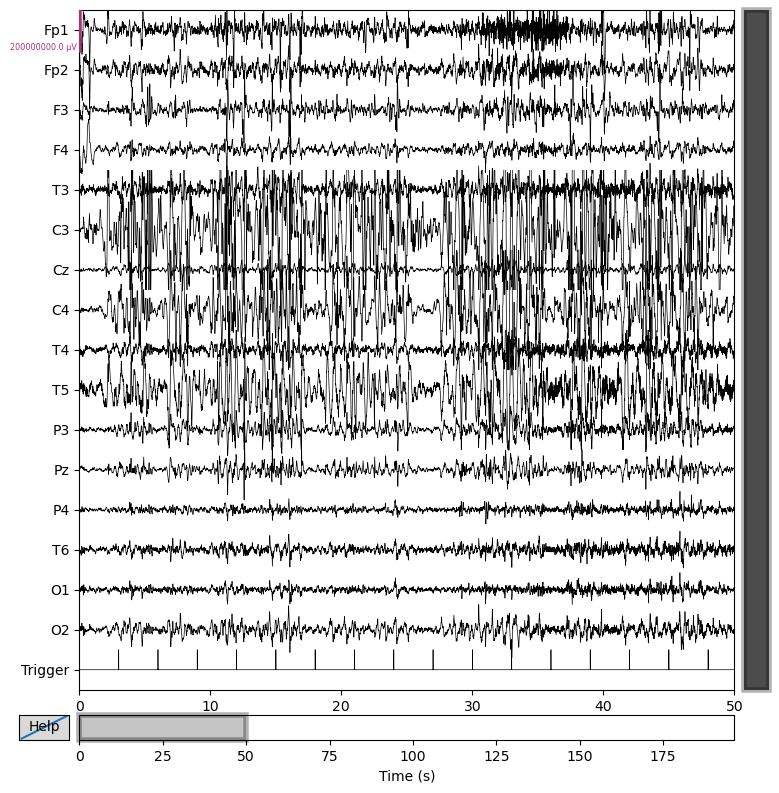

lag: 
-3.0
[1264396.3594569236, 1264396.3660656319]
[0 3]
L and F shapes:
(32552,)
(32552,)
(16, 32552)
(16, 32552)
65.10582453734241
65.10649970243685
-0.0006082935724407434
6.687152199447155e-05


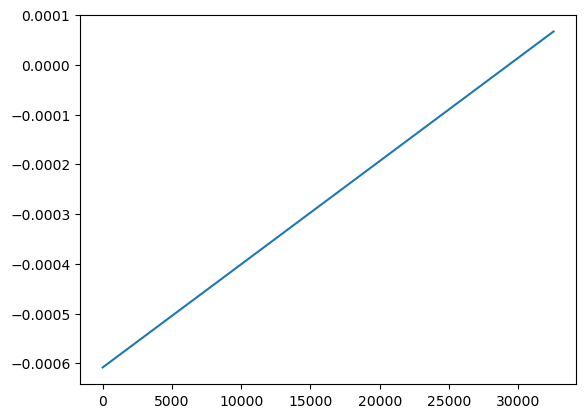

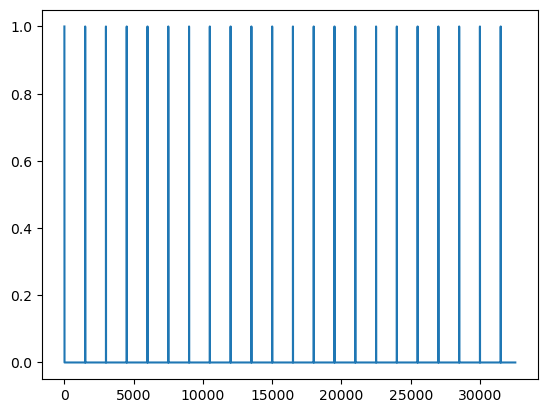

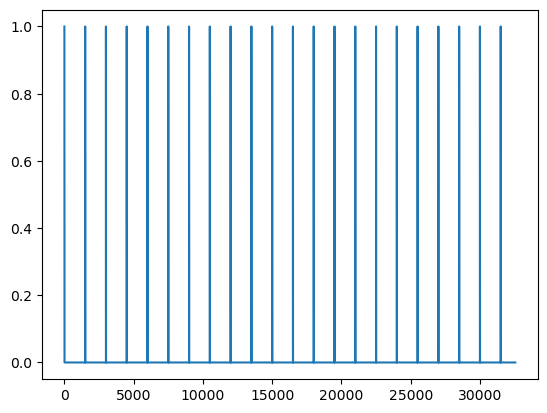

In [108]:
%matplotlib inline

nFs = 500

L = EEG_L_cleanFiltered.shape[1]
F = EEG_F_cleanFiltered.shape[1]

durL = EEG_L_cleanTS[-1] - EEG_L_cleanTS[0]
durF = EEG_F_cleanTS[-1] - EEG_F_cleanTS[0]

numL = round(durL*nFs+2)
numF = round(durF*nFs+2)

[L_resample, L_TS_resample] = signal.resample(EEG_L_cleanFiltered, numL, t=EEG_L_cleanTS, axis=1, window=None, domain='time')
[F_resample, F_TS_resample] = signal.resample(EEG_F_cleanFiltered, numF, t=EEG_F_cleanTS, axis=1, window=None, domain='time')

print(F_TS_resample.shape)
print(L_TS_resample.shape)
print(F_resample.shape)
print(L_resample.shape)

print(F_TS_resample[-1]-F_TS_resample[0])
print(L_TS_resample[-1]-L_TS_resample[0])

print(L_TS_resample[0:10]-F_TS_resample[0:10])
maxLength = np.min([F_TS_resample.shape[0],L_TS_resample.shape[0]])
print(L_TS_resample[maxLength-11:maxLength]-F_TS_resample[maxLength-11:maxLength])

plt.plot(L_TS_resample[0:maxLength]-F_TS_resample[0:maxLength]);
plt.show()

lag = np.round(np.mean(L_TS_resample[0:maxLength]-F_TS_resample[0:maxLength]),3)
print("lag: ")
print(nFs*lag)


rawLags = [L_TS_resample[0], F_TS_resample[0]]
print(rawLags)
minLag = np.argmin(rawLags) 
sampleDelay = np.round((rawLags-rawLags[minLag])*nFs).astype(int)
print(sampleDelay)

if lag>0: 
    F_TS_resample = F_TS_resample[sampleDelay[0]:-1]
    F_resample = F_resample[:,sampleDelay[0]:-1]
 
else:
    L_TS_resample = L_TS_resample[sampleDelay[1]:-1] 
    L_resample = L_resample[:,sampleDelay[1]:-1]

maxLength = np.min([F_TS_resample.shape[0],L_TS_resample.shape[0]])

F_TS_resample = F_TS_resample[:maxLength]
F_resample = F_resample[:,:maxLength]
L_TS_resample = L_TS_resample[:maxLength] 
L_resample = L_resample[:,:maxLength]  

print('L and F shapes:')
print(F_TS_resample.shape)
print(L_TS_resample.shape)
print(F_resample.shape)
print(L_resample.shape)

# create a trigger time series with triggers every 3 seconds
trigger_interval = 3  # seconds
trigger_F = np.zeros(F_TS_resample.shape[0])
trigger_L = np.zeros(L_TS_resample.shape[0])

trigger_times_F = np.arange(F_TS_resample[0], F_TS_resample[-1], trigger_interval)
trigger_times_L = np.arange(L_TS_resample[0], L_TS_resample[-1], trigger_interval)

for t in trigger_times_F:
    idx = np.argmin(np.abs(F_TS_resample - t))
    trigger_F[idx] = 1

for t in trigger_times_L:
    idx = np.argmin(np.abs(L_TS_resample - t))
    trigger_L[idx] = 1



print(F_TS_resample[-1]-F_TS_resample[0])  
print(L_TS_resample[-1]-L_TS_resample[0])

print(L_TS_resample[0]-F_TS_resample[0])
print(L_TS_resample[-1]-F_TS_resample[-1])

plt.plot(L_TS_resample[0:maxLength]-F_TS_resample[0:maxLength]);
plt.show()

plt.plot(trigger_F);
plt.show()
plt.plot(trigger_L);
plt.show()

In [109]:

raw_data_lead = np.concatenate((L_resample, trigger_L.reshape(1,len(trigger_L))), axis=0)
raw_data_follow = np.concatenate((F_resample, trigger_F.reshape(1,len(trigger_F))), axis=0)

info = mne.create_info(ch_names=ch_names, sfreq=nFs, ch_types=ch_types)
raw_L = mne.io.RawArray(raw_data_lead, info)
raw_F = mne.io.RawArray(raw_data_follow, info)

raw_L.filter(1, 35, method='iir')
raw_F.filter(1, 35, method='iir')

raw_L.save('raw_L.fif', overwrite=True)
raw_F.save('raw_F.fif', overwrite=True)

Creating RawArray with float64 data, n_channels=17, n_times=32552
    Range : 0 ... 32551 =      0.000 ...    65.102 secs
Ready.
Creating RawArray with float64 data, n_channels=17, n_times=32552
    Range : 0 ... 32551 =      0.000 ...    65.102 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 35.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 35 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 35.00 Hz: -6.02, -6.02 dB

Overwriting existing file.
Writing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_L.fif
Closing d:\Documents

C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\2501744668.py:11: RuntimeWarning: This filename (d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_L.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_L.save('raw_L.fif', overwrite=True)
C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\2501744668.py:12: RuntimeWarning: This filename (d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_F.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_F.save('raw_F.fif', overwrite=True)


(33, 32552)
['L_Fp1', 'L_Fp2', 'L_F3', 'L_F4', 'L_T3', 'L_C3', 'L_Cz', 'L_C4', 'L_T4', 'L_T5', 'L_P3', 'L_Pz', 'L_P4', 'L_T6', 'L_O1', 'L_O2', 'F_Fp1', 'F_Fp2', 'F_F3', 'F_F4', 'F_T3', 'F_C3', 'F_Cz', 'F_C4', 'F_T4', 'F_T5', 'F_P3', 'F_Pz', 'F_P4', 'F_T6', 'F_O1', 'F_O2', 'Trigger']
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']
Creating RawArray with float64 data, n_channels=33, n_times=32552
    Range : 0 ... 32551 =      0.000 ...    65.102 secs
Ready.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.


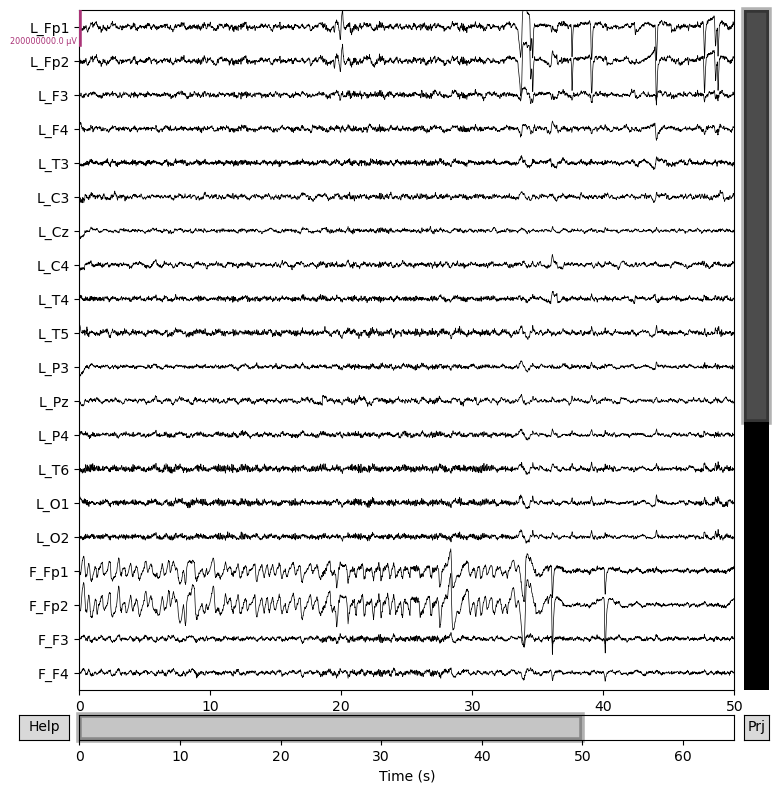

In [110]:
concat_rest = np.concatenate((L_resample, F_resample, trigger_L.reshape(1,len(trigger_L))), axis=0)
print(concat_rest.shape)

concat_ch_names = [f'L_{ch}' for ch in ch_names[:-1]] + [f'F_{ch}' for ch in ch_names[:-1]] + ['Trigger']
concat_ch_types = ['eeg'] * (len(ch_names)-1)*2 + ['stim']
print(concat_ch_names)
print(concat_ch_types)
info = mne.create_info(ch_names=concat_ch_names, sfreq=nFs, ch_types=concat_ch_types)
raw_rest_combined = mne.io.RawArray(concat_rest, info)

raw_rest_combined.filter(0.5, 35, method='iir', iir_params=dict(order=4, ftype='butter'), verbose=False)
raw_rest_combined.set_eeg_reference('average', projection=True)
raw_rest_combined.plot(scalings=dict(eeg=100), duration=50, start=0, remove_dc=True);

In [74]:
# save raw_rest_combined to a .fif file
raw_rest_combined.save('raw_rest_combined.fif', overwrite=True)

Overwriting existing file.
Writing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_rest_combined.fif
Closing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_rest_combined.fif
[done]


C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\2567117022.py:2: RuntimeWarning: This filename (d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_rest_combined.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_rest_combined.save('raw_rest_combined.fif', overwrite=True)


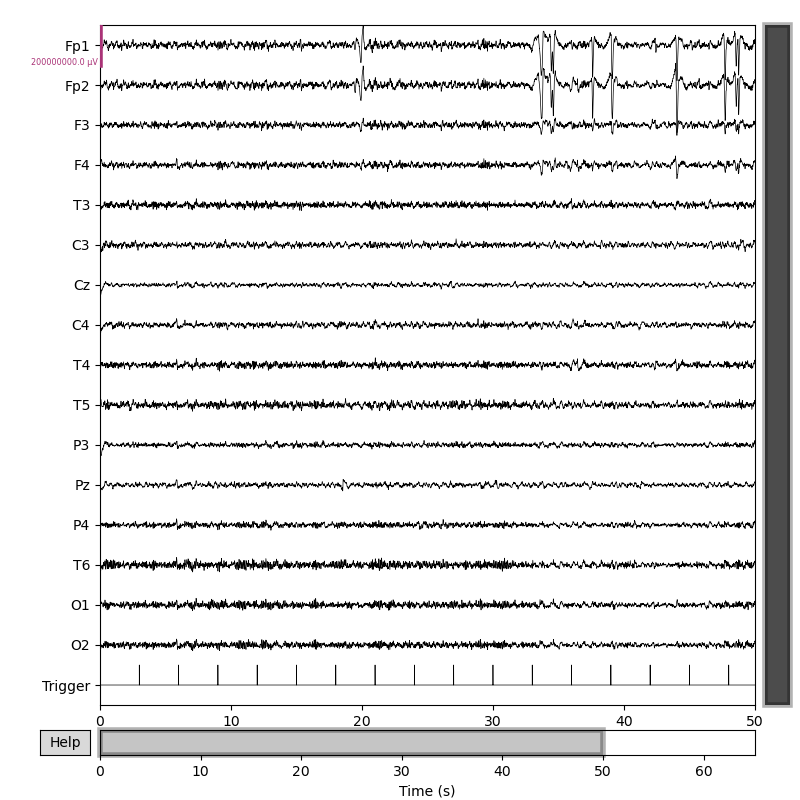

In [111]:
%matplotlib ipympl
# raw_L.filter(0.5, 35, method='iir', iir_params=dict(order=4, ftype='butter'), verbose=False)
raw_L.plot(scalings=dict(eeg=100), duration=50, start=0, remove_dc=True);


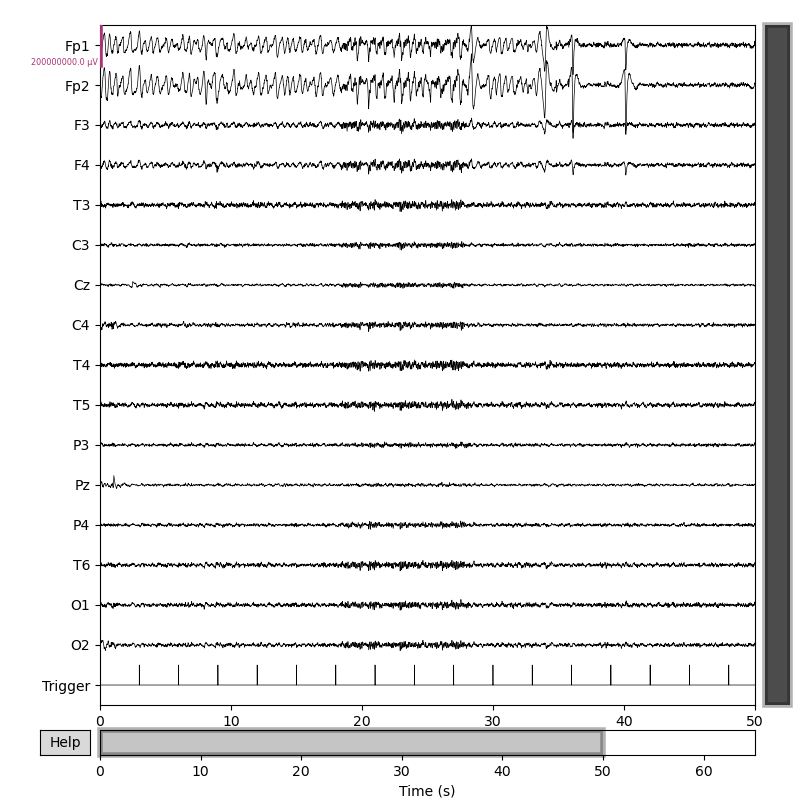

In [112]:
raw_F.filter(0.5, 35, method='iir', iir_params=dict(order=4, ftype='butter'), verbose=False)
raw_F.plot(scalings=dict(eeg=100), duration=50, start=0, remove_dc=True);

In [120]:
# load raw_L and raw_F from .fif files
raw_L = mne.io.read_raw_fif('raw_L.fif', preload=True)
raw_F = mne.io.read_raw_fif('raw_F.fif', preload=True)

Opening raw data file raw_L.fif...
Isotrak not found
    Range : 0 ... 32551 =      0.000 ...    65.102 secs
Ready.
Reading 0 ... 32551  =      0.000 ...    65.102 secs...
Opening raw data file raw_F.fif...
Isotrak not found
    Range : 0 ... 32551 =      0.000 ...    65.102 secs
Ready.
Reading 0 ... 32551  =      0.000 ...    65.102 secs...


C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\2485958536.py:2: RuntimeWarning: This filename (raw_L.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_L = mne.io.read_raw_fif('raw_L.fif', preload=True)
C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\2485958536.py:3: RuntimeWarning: This filename (raw_F.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_F = mne.io.read_raw_fif('raw_F.fif', preload=True)


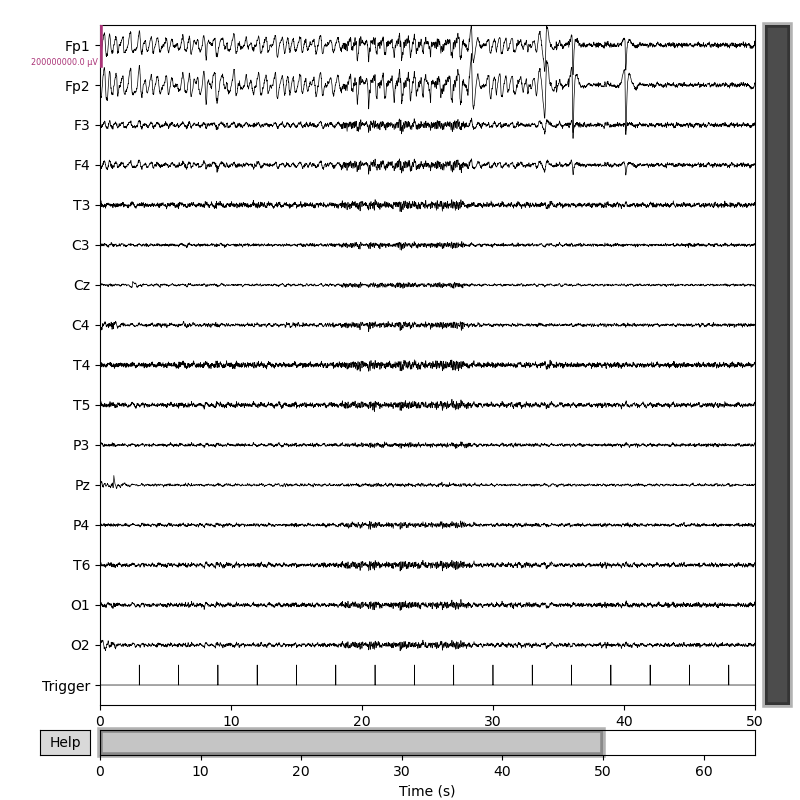

In [116]:
raw_F.plot(scalings=dict(eeg=100), duration=50, start=0, remove_dc=True);

In [117]:
from asrpy import ASR

asr_lead = ASR(sfreq=raw_L.info["sfreq"], cutoff=10)
asr_lead.fit(raw_L)



In [121]:
asr_follow = ASR(sfreq=raw_F.info["sfreq"], cutoff=10)
asr_follow.fit(raw_F)

In [64]:
eventsClean = mne.make_fixed_length_events(raw_rest_combined, start=4, duration=3.0)
epochClean = mne.Epochs(raw_rest_combined, eventsClean, tmin=-3, tmax=3, baseline=None, preload=True)

# Get the data from the epochs
print("Calculating baseline connectivity...")
epochCleanArray = epochClean.get_data(copy=False)
print(nChan)
epochBaselineArray_lead = epochCleanArray[:,0:nChan,:]
epochBaselineArray_folllow = epochCleanArray[:,nChan:nChan*2,:]

print(epochBaselineArray_lead.shape)
print(epochBaselineArray_folllow.shape)
# epochBaselineArray_lead_subset = epochBaselineArray_lead[:, subset_indices, :]
# epochBaselineArray_folllow_subset = epochBaselineArray_folllow[:, subset_indices, :]
epochBaselineArray_comb = np.array([epochBaselineArray_lead,epochBaselineArray_folllow])

EpochBaselineComplex = analyses.compute_freq_bands(epochBaselineArray_comb, freq_bands=freq_bands, sampling_rate = nFs)
ConnCoh = analyses.compute_sync(EpochBaselineComplex, mode = 'coh', epochs_average = False)
BaselineConn= np.mean(ConnCoh[0,:,:,:],axis=0)

Not setting metadata
20 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 20 events and 3001 original time points ...
0 bad epochs dropped
Calculating baseline connectivity...
16
(20, 16, 3001)
(20, 16, 3001)


# Simple movements

In [125]:
for i, stream in enumerate(simplestreams):
    print(i, end=' ')
    print(stream['info']['name'], end=' ')
    print(stream['info']['type'])
    if stream['info']['name'][0] == 'my_obci_EXG_COM12':
        EEG_L_simple = stream["time_series"]
        EEG_L_simpleTS = stream["time_stamps"]
        EEG_L_simpleSR = stream['info']['effective_srate']
        print('simple lead EEG stream successfully read')
    elif stream['info']['name'][0] == 'my_obci_EXG_COM7':
        EEG_F_simple = stream["time_series"]   
        EEG_F_simpleTS = stream["time_stamps"]
        EEG_F_simpleSR = stream['info']['effective_srate']
        print('simple follow EEG stream successfully read')
    elif stream['info']['name'][0] == 'FrameMarker1':
        video = stream["time_series"]
        videoTS = stream["time_stamps"]
        print('video stream successfully read')
    

0 ['follower-right'] ['IMU']
1 ['leader-left'] ['IMU']
2 ['my_obci_AUX_COM7'] ['AUX']
3 ['my_obci_AUX_COM12'] ['AUX']
4 ['follower-body'] ['IMU']
5 ['leader-body'] ['IMU']
6 ['leader-right'] ['IMU']
7 ['follower-left'] ['IMU']
8 ['my_obci_EXG_COM7'] ['EXG']
simple follow EEG stream successfully read
9 ['FrameMarker1'] ['videostream']
video stream successfully read
10 ['my_obci_EXG_COM12'] ['EXG']
simple lead EEG stream successfully read


In [126]:
# get first frame of the video stream
first_frame = video[0][0]
print("first frame: ")
print(first_frame)

first frame: 
172.0


(98198,)
(98199,)
(16, 98198)
(16, 98199)
196.39796537626535
196.39979500765912
[-0.0070273  -0.0070273  -0.0070273  -0.0070273  -0.0070273  -0.00702731
 -0.00702731 -0.00702731 -0.00702731 -0.00702731]
[-0.00719769 -0.00719769 -0.00719769 -0.00719769 -0.00719769 -0.0071977
 -0.0071977  -0.0071977  -0.0071977  -0.0071977  -0.0071977 ]


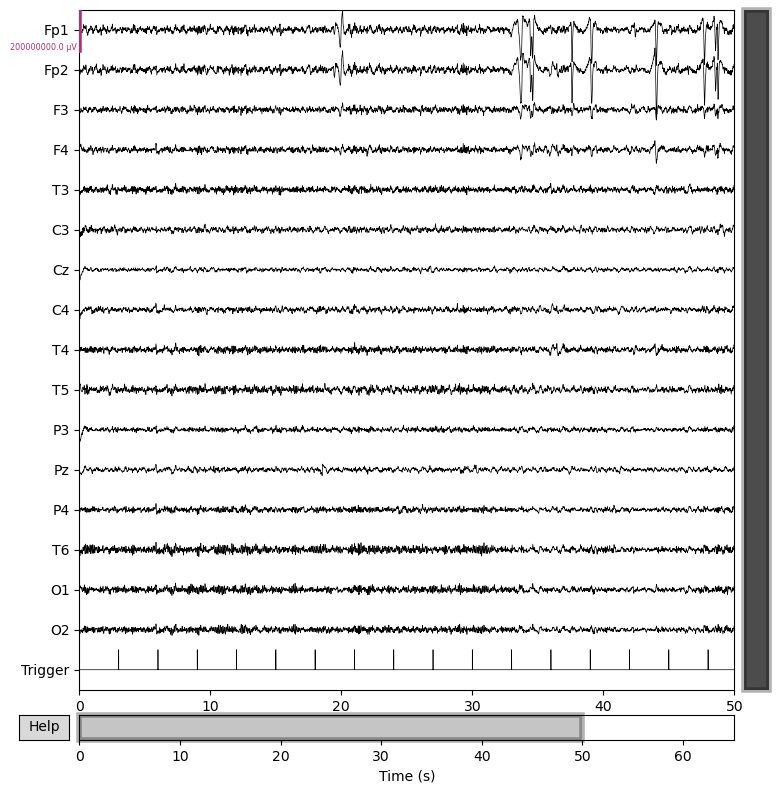

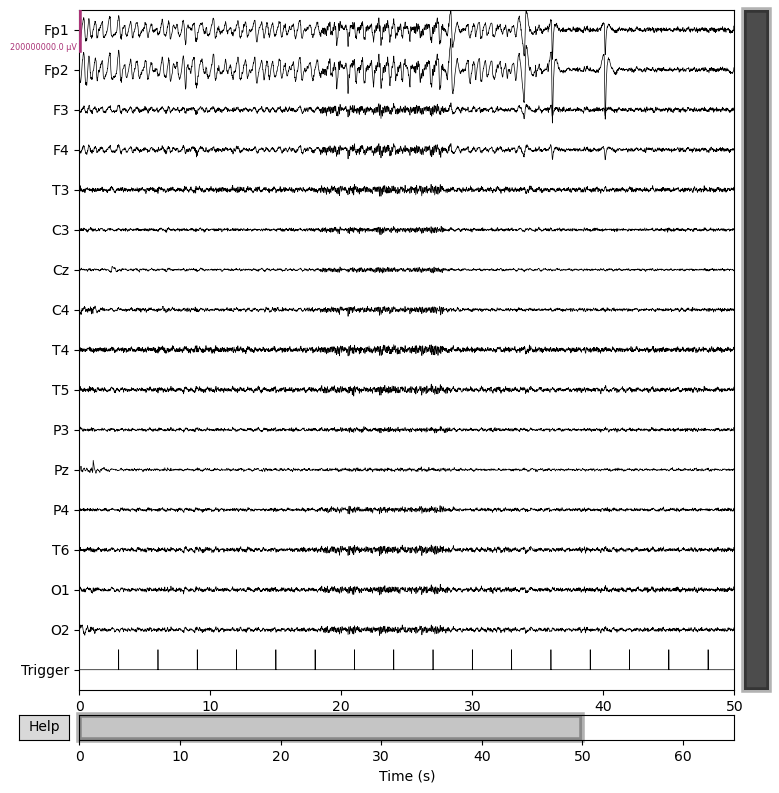

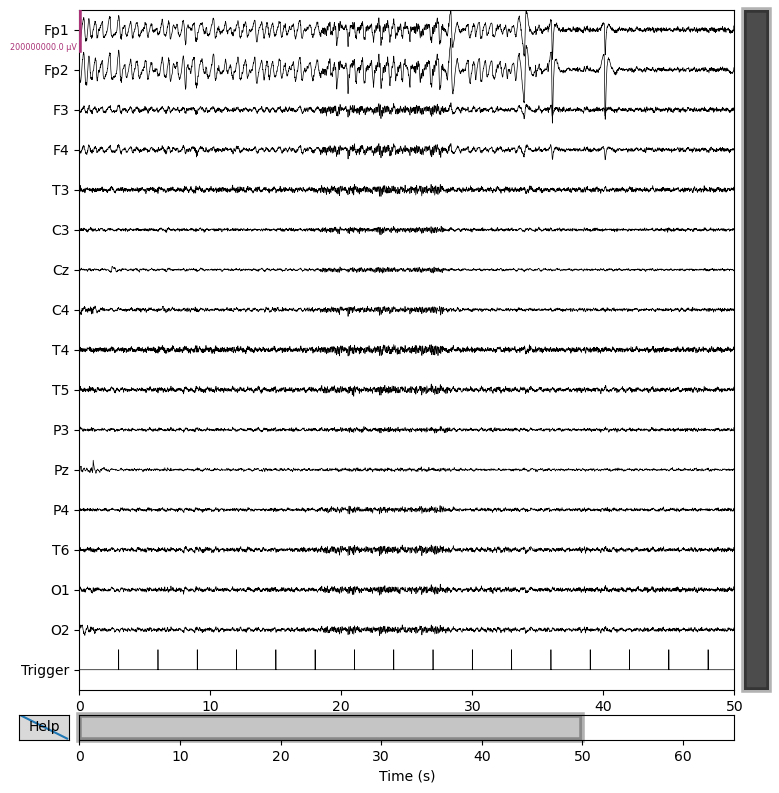

lag: 
-3.5
[1264865.3307971254, 1264865.3378244224]
[0 4]
L and F shapes:
(98194,)
(98194,)
(16, 98194)
(16, 98194)
196.38996521476656
196.3897948146332
0.000972857465967536
0.000802457332611084


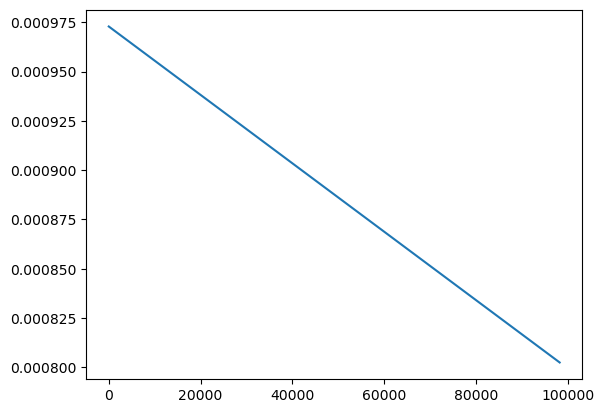

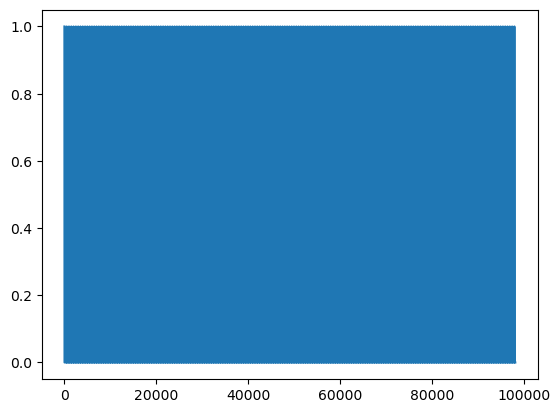

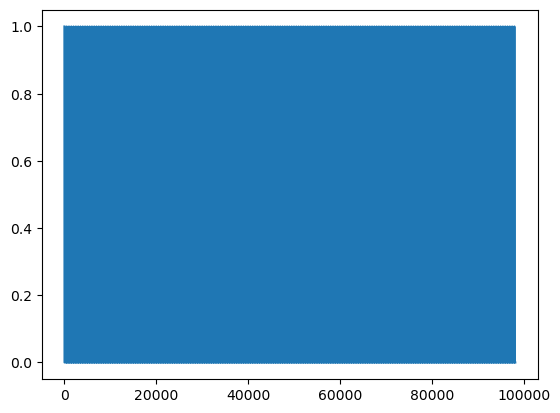

In [127]:
%matplotlib inline

nFs = 500

L = EEG_L_simple.T.shape[1]
F = EEG_F_simple.T.shape[1]

durL = EEG_L_simpleTS[-1] - EEG_L_simpleTS[0]
durF = EEG_F_simpleTS[-1] - EEG_F_simpleTS[0]

numL = round(durL*nFs+2)
numF = round(durF*nFs+2)

[L_resample, L_TS_resample] = signal.resample(EEG_L_simple.T, numL, t=EEG_L_simpleTS, axis=1, window=None, domain='time')
[F_resample, F_TS_resample] = signal.resample(EEG_F_simple.T, numF, t=EEG_F_simpleTS, axis=1, window=None, domain='time')

print(F_TS_resample.shape)
print(L_TS_resample.shape)
print(F_resample.shape)
print(L_resample.shape)

print(F_TS_resample[-1]-F_TS_resample[0])
print(L_TS_resample[-1]-L_TS_resample[0])

print(L_TS_resample[0:10]-F_TS_resample[0:10])
maxLength = np.min([F_TS_resample.shape[0],L_TS_resample.shape[0]])
print(L_TS_resample[maxLength-11:maxLength]-F_TS_resample[maxLength-11:maxLength])

plt.plot(L_TS_resample[0:maxLength]-F_TS_resample[0:maxLength]);
plt.show()

lag = np.round(np.mean(L_TS_resample[0:maxLength]-F_TS_resample[0:maxLength]),3)
print("lag: ")
print(nFs*lag)


rawLags = [L_TS_resample[0], F_TS_resample[0]]
print(rawLags)
minLag = np.argmin(rawLags) 
sampleDelay = np.round((rawLags-rawLags[minLag])*nFs).astype(int)
print(sampleDelay)

if lag>0: 
    F_TS_resample = F_TS_resample[sampleDelay[0]:-1]
    F_resample = F_resample[:,sampleDelay[0]:-1]
 
else:
    L_TS_resample = L_TS_resample[sampleDelay[1]:-1] 
    L_resample = L_resample[:,sampleDelay[1]:-1]

maxLength = np.min([F_TS_resample.shape[0],L_TS_resample.shape[0]])

F_TS_resample = F_TS_resample[:maxLength]
F_resample = F_resample[:,:maxLength]
L_TS_resample = L_TS_resample[:maxLength] 
L_resample = L_resample[:,:maxLength]  

print('L and F shapes:')
print(F_TS_resample.shape)
print(L_TS_resample.shape)
print(F_resample.shape)
print(L_resample.shape)

# create a trigger time series with triggers every 3 seconds
trigger_interval = 1  # seconds
trigger_F = np.zeros(F_TS_resample.shape[0])
trigger_L = np.zeros(L_TS_resample.shape[0])

trigger_times_F = np.arange(F_TS_resample[0], F_TS_resample[-1], trigger_interval)
trigger_times_L = np.arange(L_TS_resample[0], L_TS_resample[-1], trigger_interval)

for t in trigger_times_F:
    idx = np.argmin(np.abs(F_TS_resample - t))
    trigger_F[idx] = 1

for t in trigger_times_L:
    idx = np.argmin(np.abs(L_TS_resample - t))
    trigger_L[idx] = 1



print(F_TS_resample[-1]-F_TS_resample[0])  
print(L_TS_resample[-1]-L_TS_resample[0])

print(L_TS_resample[0]-F_TS_resample[0])
print(L_TS_resample[-1]-F_TS_resample[-1])

plt.plot(L_TS_resample[0:maxLength]-F_TS_resample[0:maxLength]);
plt.show()

plt.plot(trigger_F);
plt.show()
plt.plot(trigger_L);
plt.show()

In [128]:
# create a mne object for each stream and filter it
info_L = mne.create_info(ch_names=ch_names, sfreq=nFs, ch_types=ch_types)
raw_L_simple = mne.io.RawArray(np.concatenate((L_resample, trigger_L.reshape(1,len(trigger_L))), axis=0), info_L)
# raw_L_simple.filter(0.5, 35, method='iir', iir_params=dict(order=4, ftype='butter'), verbose=False)

info_F = mne.create_info(ch_names=ch_names, sfreq=nFs, ch_types=ch_types)
raw_F_simple = mne.io.RawArray(np.concatenate((F_resample, trigger_F.reshape(1,len(trigger_F))), axis=0), info_F)
# raw_F_simple.filter(0.5, 35, method='iir', iir_params=dict(order=4, ftype='butter'), verbose=False)

Creating RawArray with float64 data, n_channels=17, n_times=98194
    Range : 0 ... 98193 =      0.000 ...   196.386 secs
Ready.
Creating RawArray with float64 data, n_channels=17, n_times=98194
    Range : 0 ... 98193 =      0.000 ...   196.386 secs
Ready.


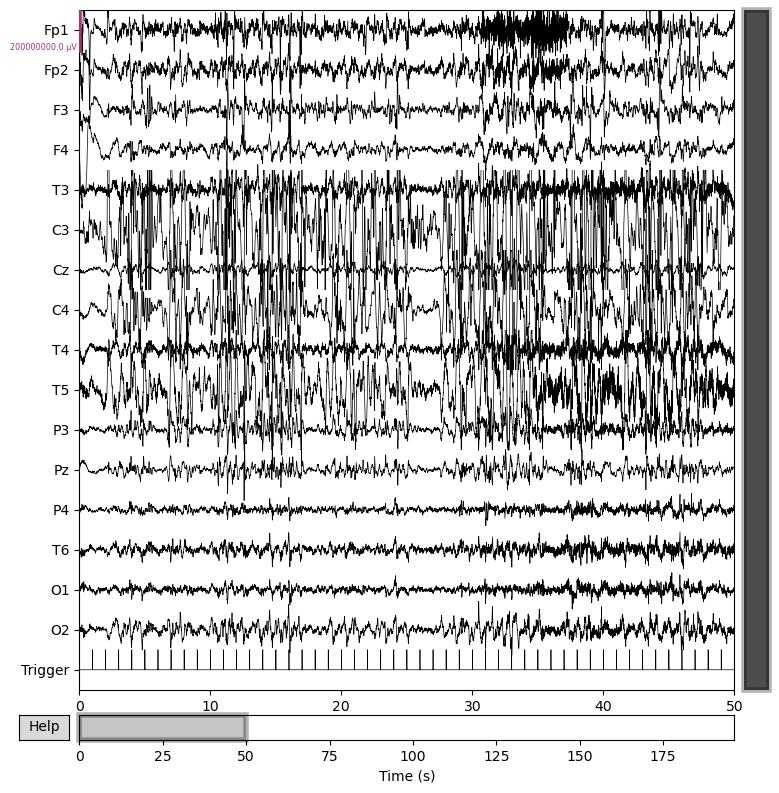

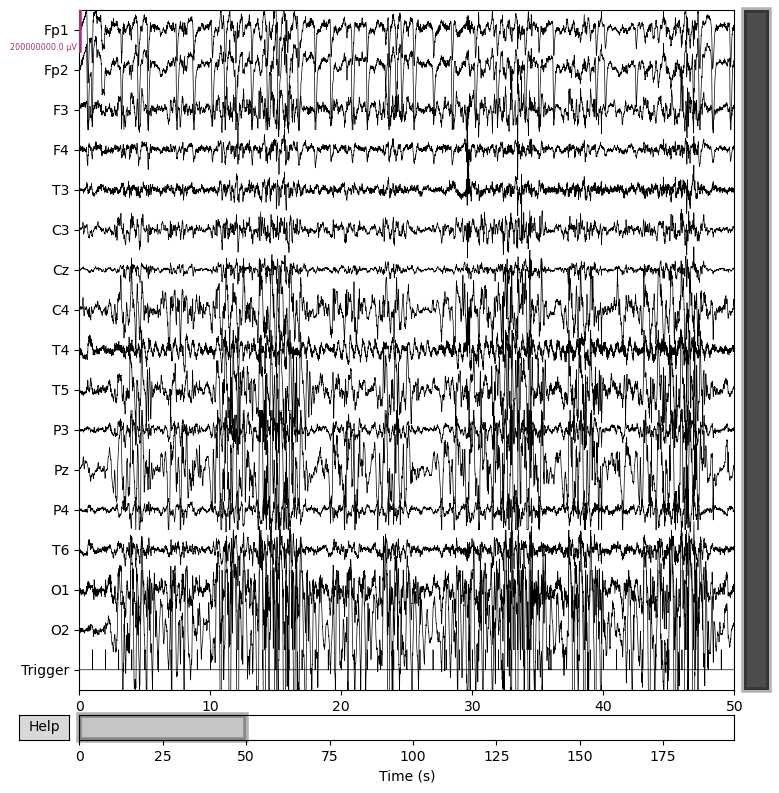

In [129]:
raw_L_simple.filter(0.5, 45, method='iir', iir_params=dict(order=4, ftype='butter'), verbose=False)
raw_L_simple.plot(scalings=dict(eeg=100), duration=50, start=0, remove_dc=True);
raw_F_simple.filter(0.5, 45, method='iir', iir_params=dict(order=4, ftype='butter'), verbose=False)
raw_F_simple.plot(scalings=dict(eeg=100), duration=50, start=0, remove_dc=True);

In [130]:
# save raw_L_simple and raw_F_simple as .fif files
raw_L_simple.save('raw_L_simple.fif', overwrite=True)
raw_F_simple.save('raw_F_simple.fif', overwrite=True)

Overwriting existing file.
Writing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_L_simple.fif
Closing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_L_simple.fif
[done]
Overwriting existing file.
Writing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_F_simple.fif
Closing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_F_simple.fif
[done]


C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\3016085734.py:2: RuntimeWarning: This filename (d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_L_simple.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_L_simple.save('raw_L_simple.fif', overwrite=True)
C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\3016085734.py:3: RuntimeWarning: This filename (d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_F_simple.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_F_simple.save('raw_F_simple.fif', overwrite=True)


In [131]:
ASR_L = asr_lead.transform(raw_L_simple.filter(l_freq=0.5, h_freq=45.), picks='eeg')
ASR_F = asr_follow.transform(raw_F_simple.filter(l_freq=0.5, h_freq=45.), picks='eeg')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 3301 samples (6.602 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband ed

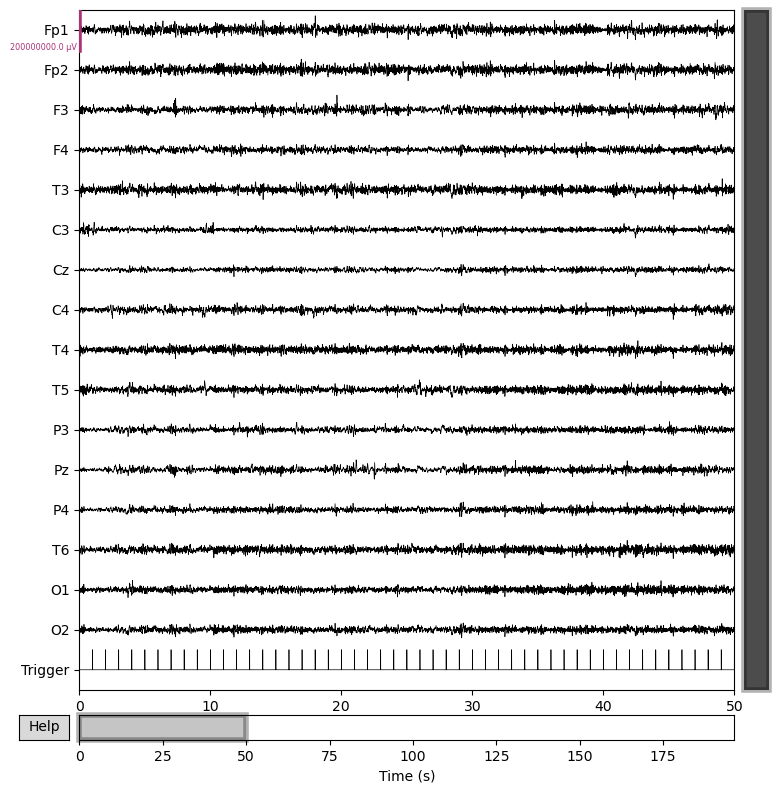

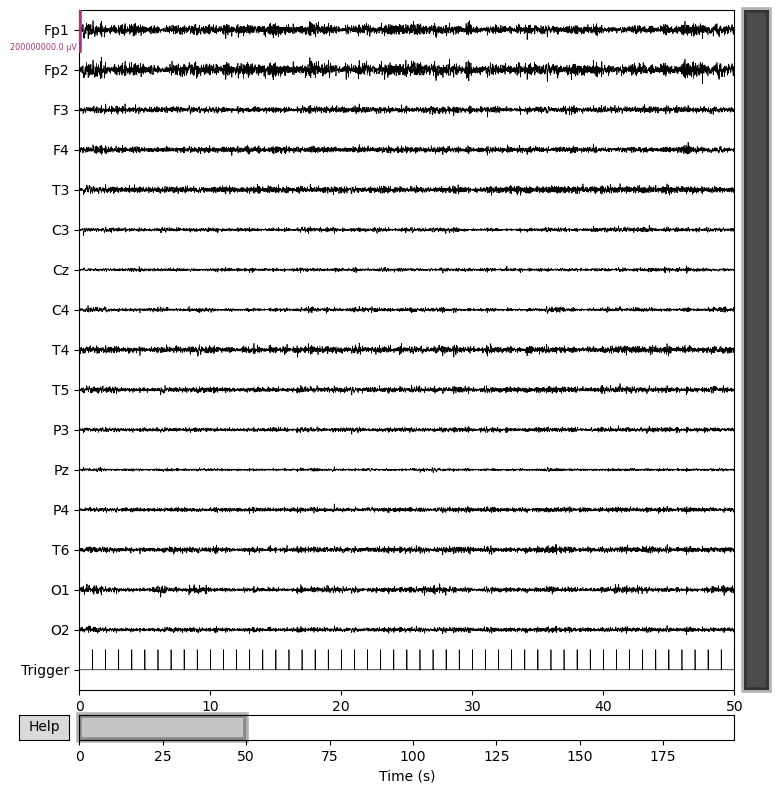

In [132]:
ASR_L.plot(scalings=dict(eeg=100), duration=50, start=0, remove_dc=True);
ASR_F.plot(scalings=dict(eeg=100), duration=50, start=0, remove_dc=True);

In [133]:
# save ASR_L and ASR_F as .fif files
ASR_L.save('raw_ASR_L_simple.fif', overwrite=True)
ASR_F.save('raw_ASR_F_simple.fif', overwrite=True)

Overwriting existing file.
Writing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_ASR_L_simple.fif
Closing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_ASR_L_simple.fif
[done]
Overwriting existing file.
Writing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_ASR_F_simple.fif
Closing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_ASR_F_simple.fif
[done]


C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\1445271753.py:2: RuntimeWarning: This filename (d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_ASR_L_simple.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  ASR_L.save('raw_ASR_L_simple.fif', overwrite=True)
C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\1445271753.py:3: RuntimeWarning: This filename (d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_ASR_F_simple.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  ASR_F.save('raw_ASR_F_simple.fif', overwrite=True)


In [134]:
# combine ASR_L and ASR_F into a single mne object
concat_simple = np.concatenate((ASR_L.get_data(picks='eeg'), ASR_F.get_data(picks='eeg'), trigger_L.reshape(1,len(trigger_L))), axis=0)
concat_ch_names = [f'L_{ch}' for ch in ch_names[:-1]] + [f'F_{ch}' for ch in ch_names[:-1]] + ['Trigger']
concat_ch_types = ['eeg'] * (len(ch_names)-1)*2 + ['stim']
info_concat = mne.create_info(ch_names=concat_ch_names, sfreq=nFs, ch_types=concat_ch_types)
raw_simple_combined = mne.io.RawArray(concat_simple, info_concat)

Creating RawArray with float64 data, n_channels=33, n_times=98194
    Range : 0 ... 98193 =      0.000 ...   196.386 secs
Ready.


In [135]:
raw_simple_combined.save('raw_simple_combined.fif', overwrite=True)

Overwriting existing file.
Writing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_simple_combined.fif
Closing d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_simple_combined.fif
[done]


C:\Users\thiag\AppData\Local\Temp\ipykernel_40852\4068555640.py:1: RuntimeWarning: This filename (d:\Documents\Git_Repos\Real-time_EEG-Hyperscanning\raw_simple_combined.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_simple_combined.save('raw_simple_combined.fif', overwrite=True)


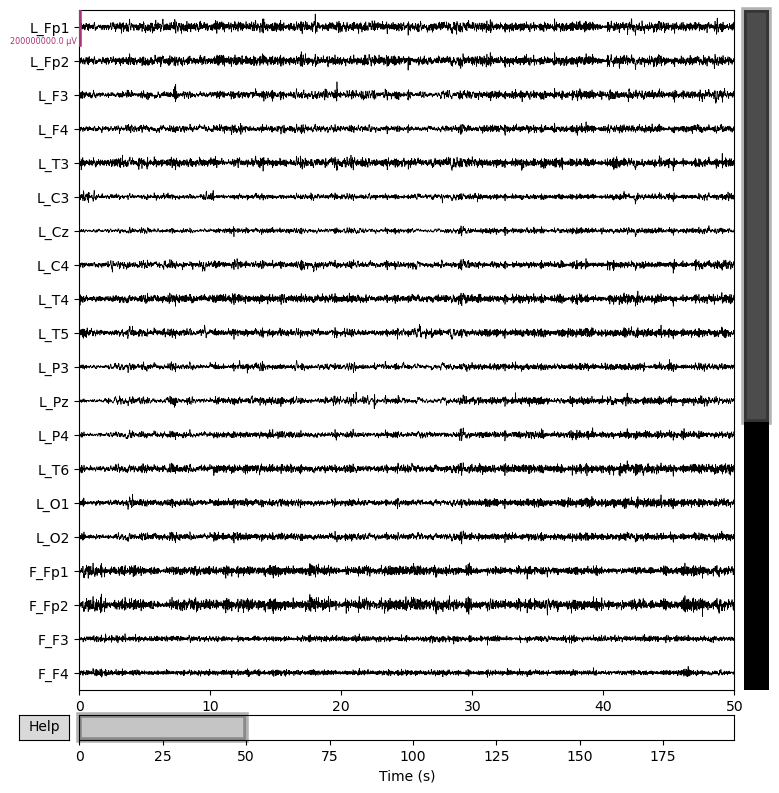

In [136]:
raw_simple_combined.plot(scalings=dict(eeg=100), duration=50, start=0, remove_dc=True);

# epoch from triggers

In [61]:
# epoch from triggers
events_L = mne.find_events(ASR_L, stim_channel='Trigger')
events_F = mne.find_events(ASR_F, stim_channel='Trigger')

epochs_L = mne.Epochs(ASR_L, events_L, event_id=1, tmin=-3, tmax=3, baseline=(None, 0), preload=True, picks='eeg')
epochs_F = mne.Epochs(ASR_F, events_F, event_id=1, tmin=-3, tmax=3, baseline=(None, 0), preload=True, picks='eeg')

# epochs_L.plot(n_epochs=10, n_channels=16, scalings=dict(eeg=100), remove_dc=True);
# epochs_F.plot(n_epochs=10, n_channels=16, scalings=dict(eeg=100), remove_dc=True);

Trigger channel Trigger has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
65 events found on stim channel Trigger
Event IDs: [1]
Trigger channel Trigger has a non-zero initial value of {initial_value} (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
65 events found on stim channel Trigger
Event IDs: [1]
Not setting metadata
65 matching events found
Setting baseline interval to [-3.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 65 events and 3001 original time points ...
1 bad epochs dropped
Not setting metadata
65 matching events found
Setting baseline interval to [-3.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 65 events and 3001 original time points ...
1 bad epochs dropped


In [62]:
# Concatenate epochs to have the shape (n_epochs, 2*nChan, n_times)
HypClenEpochs = np.stack([epochs_L, epochs_F])  # shape: (2, 5, 10, 750)
print("HypClenEpochs.shape:", HypClenEpochs.shape)


HypClenEpochs.shape: (2, 64, 16, 3001)


In [ ]:



subset_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'Cz', 'P3', 'P4', 'Pz']
subset_indices = [ch_names.index(name) for name in subset_names]

# Compute connectivity/coherence
complex_epochs = analyses.compute_freq_bands(HypClenEpochs, freq_bands=freq_bands, sampling_rate=nFs)
print("complex_epochs.shape:", complex_epochs.shape)

conn_coh = analyses.compute_sync(complex_epochs, mode='coh', epochs_average=True)
print(f"conn_coh: {conn_coh}")
print(f"BaselineConn: {BaselineConn}")

complex_epochs.shape: (2, 64, 16, 1, 3001)
conn_coh: [[[1.         0.76600401 0.52463756 ... 0.10589336 0.10624783 0.09807393]
  [0.76600401 1.         0.42183346 ... 0.09622167 0.10818773 0.09590594]
  [0.52463756 0.42183346 1.         ... 0.13232775 0.12976813 0.14046553]
  ...
  [0.10589336 0.09622167 0.13232775 ... 1.         0.54589165 0.9065962 ]
  [0.10624783 0.10818773 0.12976813 ... 0.54589165 1.         0.76397335]
  [0.09807393 0.09590594 0.14046553 ... 0.9065962  0.76397335 1.        ]]]


NameError: name 'BaselineConn' is not defined

In [124]:
subset_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'Cz', 'P3', 'P4', 'Pz']
subset_indices_L = [ch_names.index(name) for name in subset_names]
subset_indices_F = [ch_names.index(name) + nChan for name in subset_names]
print(subset_indices_L)
print(subset_indices_F)

# get subset from conn_coh
conn_coh_subset = conn_coh[:, subset_indices_L][:, :, subset_indices_F]
print("conn_coh_subset.shape:", conn_coh_subset.shape)
# compute mean across epochs
mean_conn_coh_subset = np.mean(conn_coh_subset, axis=0)
print("mean_conn_coh_subset.shape:", mean_conn_coh_subset.shape)
# compute mean across frequencies
mean_conn_coh_subset_freq = np.mean(mean_conn_coh_subset, axis=0)
print("mean_conn_coh_subset_freq.shape:", mean_conn_coh_subset_freq.shape)



[0, 1, 2, 3, 5, 7, 6, 10, 12, 11]
[16, 17, 18, 19, 21, 23, 22, 26, 28, 27]


NameError: name 'conn_coh' is not defined